In [3]:
%cd /home/dani/projects/neuroscience

/home/dani/projects/neuroscience


In [4]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import numpy as np

import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

%matplotlib inline
import matplotlib.pyplot as plt

from nilearn import datasets
import random
import torchsde

In [5]:
b_size, state_size, brownian_size = 32, 10, 2
t_size = 20

In [6]:
def set_seed(seed: int = 42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [7]:
atlas = datasets.fetch_atlas_msdl()

data = []
for i in range(30):
    x = np.load(f"data_processed/adhd/timeseries_{i}.npy").astype(np.float32)
    data.append(x)

[fetch_atlas_msdl] Dataset found in /home/dani/nilearn_data/msdl_atlas

In [8]:
print("min: ", np.min(data[0]),"max: ", np.max(data[0]))
print("mean: ", np.mean(data[0]),"std: ", np.std(data[0]))

min:  -4.191202 max:  3.6349053
mean:  3.3345255e-09 std:  0.9971551


In [9]:
def pad_and_mask(batch_ts, batch_y, eps: float = 1e-5):
    """
    Pads variable-length {ts, y} to the longest T in the batch,
    ensuring ts_pad is strictly increasing.
    """
    B = len(batch_ts)
    device = batch_y[0].device
    d = batch_y[0].shape[-1]
    lengths = [t.shape[0] for t in batch_ts]
    T_max = max(lengths)

    ts_pad_list = []
    for ts in batch_ts:
        T = len(ts)
        if T < T_max:
            # create strictly increasing padded times after the last valid ts
            Δ = eps * torch.arange(1, T_max - T + 1, device=ts.device, dtype=ts.dtype)
            ts_ext = torch.cat([ts, ts[-1:] + Δ], dim=0)
        else:
            ts_ext = ts
        ts_pad_list.append(ts_ext)

    # now all have length T_max and strictly increasing
    # we can safely take one of them (e.g., the max elementwise) or just ts_pad_list[0]
    ts_pad = torch.stack(ts_pad_list, dim=0).max(dim=0).values  # (T_max,)

    # Pad y with last value; create mask
    y_pad = torch.zeros(B, T_max, d, device=device)
    mask = torch.zeros(B, T_max, device=device)
    for i, (y, L) in enumerate(zip(batch_y, lengths)):
        y_pad[i, :L] = y
        if L < T_max:
            y_pad[i, L:] = y[L - 1]  # hold-last-value padding
        mask[i, :L] = 1.0

    return ts_pad, y_pad, mask

# ----------------------------
# Synthetic dataset (variable-length)
# ----------------------------

class VariableLengthSDEData(Dataset):
    """
    Generate 1D variable-length trajectories from a *ground-truth* SDE (OU-like),
    then we'll fit a neural SDE to them.

    dy = theta*(mu - y) dt + sigma dW_t
    """
    def __init__(self,
                 dt: float = 0.01,
                 state_size: int = 10,
                 device: str = "cpu"):
        self.data = data
        self.dt = dt
        self.state_size = state_size
        self.device = torch.device(device)
        #self._data = [self._sample_path(idx) for idx in range(len(self.data))]
        self._data = [self._sample_path(0) for _ in range(100)]
    def _sample_path(self, idx: int):
        y = torch.tensor(self.data[idx])
        ts = self.dt*torch.arange(y.shape[0], device=self.device)
        return ts, y

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self._data[idx]


def collate_variable(batch):
    # batch: list of (ts, y)
    ts_list = [b[0] for b in batch]
    y_list = [b[1] for b in batch]
    device = y_list[0].device
    ts_pad, y_pad, mask = pad_and_mask(ts_list, y_list)
    # x0 (initial states) from first timepoint of each sample
    x0 = torch.stack([y[0] for y in y_list], dim=0)  # (B, d)
    return ts_pad, y_pad, mask, x0

In [10]:
class LinearSDE(nn.Module):
    def __init__(self, state_size: int, brownian_size: int):
        super().__init__()
        self.A = nn.Parameter(1e-3*torch.randn((state_size,state_size)), requires_grad=True) # Temporal correlation and diffusion
        self.C = nn.Parameter(torch.randn((state_size, brownian_size)), requires_grad=True)  # Correlation matrix CC^T=\Sigma.
        self.noise_type = "additive"
        self.sde_type = "ito"
    
    def f(self, t, y):
        return y @ self.A.T
    
    def g(self, t, y):
        return self.C.repeat(y.size(0),1,1)

In [11]:
def masked_mse(pred, target, mask):
    # pred, target: (B, T, d); mask: (B, T)
    diff = (pred - target) ** 2  # (B, T, d)
    diff = diff.mean(dim=-1)     # (B, T)
    diff = diff * mask           # zero out padded steps
    # average over valid elements only
    denom = mask.sum().clamp_min(1.0)
    return diff.sum() / denom

In [12]:
state_size: int = 39
brownian_size = 3
#hidden: int = 64
lr: float = 1e-2
epochs: int = 100
batch_size: int = 16
method: str = "euler"  # or 'srk' / 'heun' / 'milstein' etc.
dt: float = 1e-2       # step for fixed-step solvers like euler/heun
device: str = "cuda" if torch.cuda.is_available() else "cpu"

3.130065679550171


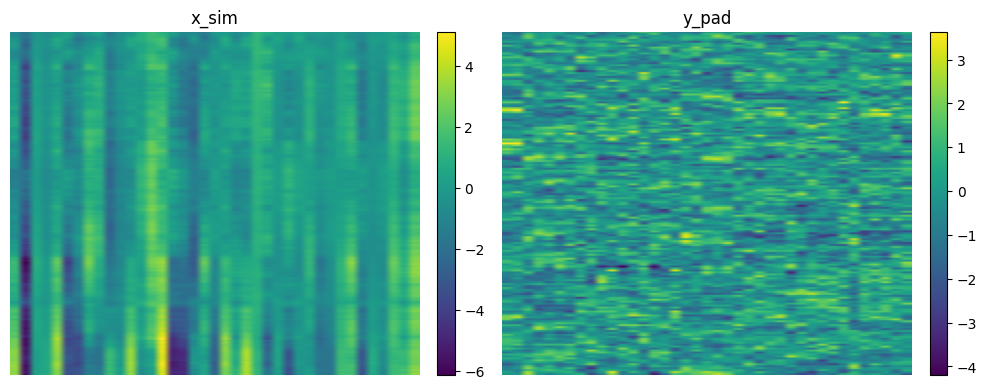

In [13]:
dataset = VariableLengthSDEData(dt=dt, state_size=state_size, device=device)
loader = DataLoader(dataset, batch_size=1, shuffle=True, collate_fn=collate_variable, drop_last=False)

# Model
sde = LinearSDE(state_size=state_size, brownian_size=brownian_size).to(device)
ts_pad, y_pad, mask, x0 = next(iter(loader))
x_sim = torchsde.sdeint(sde, x0, ts_pad, method=method).transpose(0, 1)
loss = masked_mse(x_sim, y_pad, mask)
print(loss.item())

x_data = [x_sim.detach().numpy()[0], y_pad.detach().numpy()[0]]
titles = ["x_sim", "y_pad"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, arr, title in zip(axes, x_data, titles):
    im = ax.imshow(arr, aspect="auto")
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [14]:
# Data
dataset = VariableLengthSDEData(dt=dt, state_size=state_size, device=device)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_variable, drop_last=False)

# Model
sde = LinearSDE(state_size=state_size, brownian_size=brownian_size).to(device)

In [ ]:
set_seed(123)
# Data
dataset = VariableLengthSDEData(dt=dt, state_size=state_size, device=device)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_variable, drop_last=False)

# Model
sde = LinearSDE(state_size=state_size, brownian_size=brownian_size).to(device)
optimizer = optim.Adam(sde.parameters(), lr=lr)

# Training loop
for epoch in range(1, epochs + 1):
    sde.train()
    total_loss = 0.0
    n_batches = 0

    for ts_pad, y_pad, mask, x0 in loader:
        # ts_pad: (T_max,), y_pad: (B, T_max, d), mask: (B, T_max), x0: (B, d)
        ts_pad = ts_pad.to(device)
        y_pad = y_pad.to(device)
        mask = mask.to(device)
        x0 = x0.to(device)

        optimizer.zero_grad()

        # sdeint expects state shape (B, d); returns (T, B, d)
        # Keep noise consistent per-step across batch by default BrownianMotion.
        x_sim = torchsde.sdeint(sde, x0, ts_pad, method=method)  # (T_max, B, d)

        x_sim = x_sim.transpose(0, 1)  # (B, T_max, d)

        loss = masked_mse(x_sim, y_pad, mask)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(sde.parameters(), 5.0)
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    avg_loss = total_loss / max(1, n_batches)
    print(f"Epoch {epoch:03d} | train loss: {avg_loss:.6f}")

2.5854597091674805


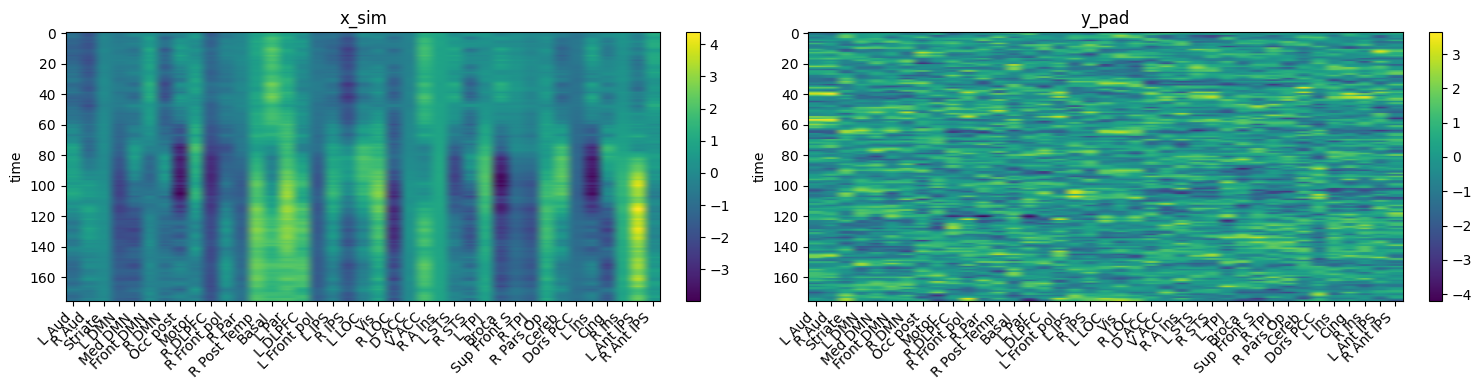

In [ ]:
#dataset = VariableLengthSDEData(dt=dt, state_size=state_size, device=device)
#loader = DataLoader(dataset, batch_size=1, shuffle=True, collate_fn=collate_variable, drop_last=False)

# Model
#sde = LinearSDE(state_size=state_size, brownian_size=brownian_size).to(device)
ts_pad, y_pad, mask, x0 = next(iter(loader))
x_sim = torchsde.sdeint(sde, x0, ts_pad, method=method).transpose(0, 1)
loss = masked_mse(x_sim, y_pad, mask)
print(loss.item())

x_data = [x_sim.detach().numpy()[0], y_pad.detach().numpy()[0]]
titles = ["simulation", "ground truth"]

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for ax, arr, title in zip(axes, x_data, titles):
    im = ax.imshow(arr, aspect="auto")
    ax.set_title(title)
    ax.set_xticks(range(len(atlas["labels"])))
    ax.set_ylabel("time")
    ax.set_xticklabels(atlas["labels"], rotation=45, ha="right")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
t, y_pad, mask, x0 = next(iter(loader))

n_samples = 30
ys = []
for _ in range(n_samples):
    ys.append(torchsde.sdeint(sde, x0, t).squeeze().detach().numpy())

ys = np.stack(ys)

In [27]:
ys = ys[:, :, 0]

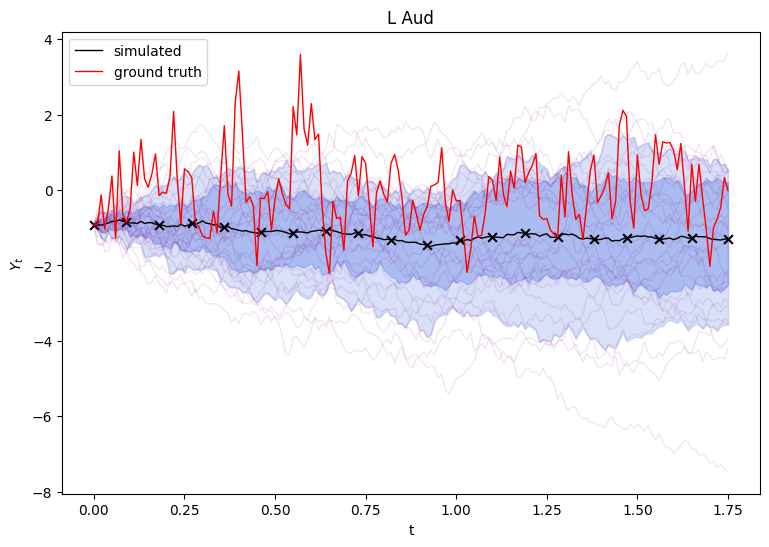

In [36]:
# Mean and quantiles
mean = ys.mean(axis=0)
q10, q25, q75, q90 = np.percentile(ys, [10, 25, 75, 90], axis=0)

# Plot
fig, ax = plt.subplots(figsize=(9,6))
ax.fill_between(t, q10, q90, color="royalblue", alpha=0.2)
ax.fill_between(t, q25, q75, color="royalblue", alpha=0.3)

# Plot sample paths
for i in range(n_samples):
    ax.plot(t, ys[i], color="purple", alpha=0.1, linewidth=1)

# Plot mean
ax.plot(t, mean, color="black", linewidth=1, label="simulated")
ax.plot(t, y_pad[0, :, 0].numpy(), color="red", linewidth=1, label="ground truth")
idx = np.linspace(0, len(t)-1, 20, dtype=int)
ax.scatter(t[idx], mean[idx], color="black", s=40, marker="x")

ax.set_title(atlas["labels"][0])
ax.set_xlabel("t")
ax.set_ylabel(r"$Y_t$")
plt.legend()
plt.show()

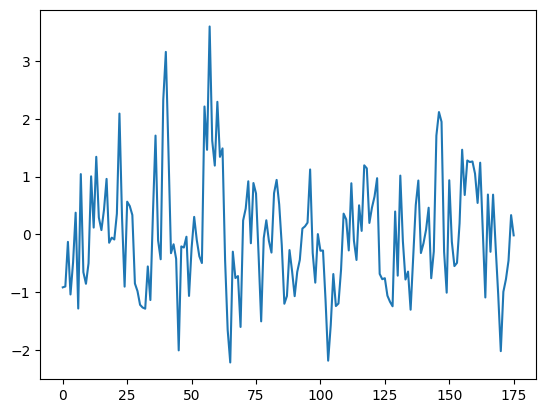

In [21]:
plt.plot(y_pad[0,:,0])